<a href="https://colab.research.google.com/github/TanviDhuri18/CSL701-CS13_Machine-Learning-Lab/blob/main/CS13_Exp2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Tanvi Dasharath Dhuri Roll no:CS13 Batch:CS01

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.


Objectives:

Understand SLR

Load/preprocess dataset

Perform EDA

Compute OLS coefficients

Evaluate with SSE, MSE, R²

Visualize regression and residual plots


Software Requirements:

Python 3.x

Jupyter/Colab/VS Code

Libraries: pandas, numpy, matplotlib, seaborn


**Algorithm**:




1.Import libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

2.Load Auto MPG dataset


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('auto-mpg.csv')   # Replace with your file name

df.head()

Saving auto-mpg.csv to auto-mpg.csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


3.Inspect and clean data


In [ ]:
print(df.info())

print(df.isnull().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774   

4.Select horsepower and mpg


In [ ]:
data = df[['horsepower','mpg']]

data = data.dropna()

print(data.head())

  horsepower   mpg
0        130  18.0
1        165  15.0
2        150  18.0
3        150  16.0
4        140  17.0


5.Plot scatter graph

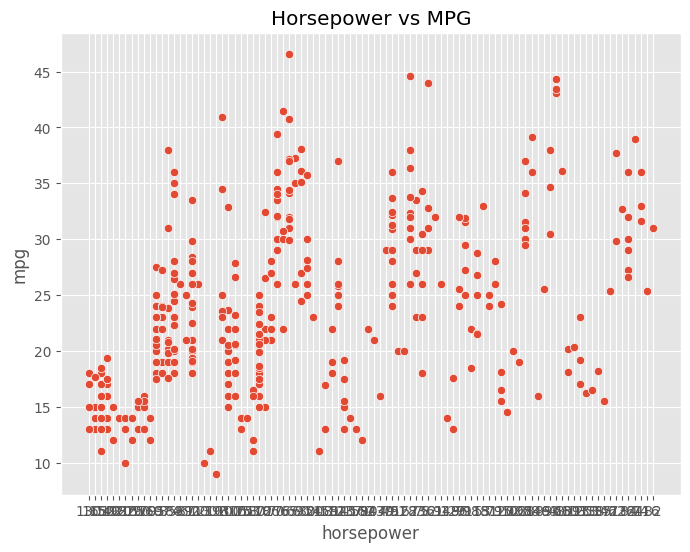

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='horsepower',y='mpg')

plt.title("Horsepower vs MPG")
plt.show()


In [ ]:
import numpy as np

# Replace '?' with NaN
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Remove missing values
df = df.dropna()

# Select only required columns
df = df[['horsepower', 'mpg']]

# Calculate correlation
corr = df.corr()
print(corr)


            horsepower       mpg
horsepower    1.000000 -0.778427
mpg          -0.778427  1.000000


6.Add bias term

In [ ]:
X = df['horsepower'].values.reshape(-1,1)

y = df['mpg'].values.reshape(-1,1)

ones = np.ones((len(X),1))

X_bias = np.hstack((ones,X))


7.Compute OLS Weights

In [ ]:
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

print("Intercept =",w[0][0])

print("Slope =",w[1][0])


Intercept = 39.9358610211705
Slope = -0.15784473335365387


8.Prediction

In [ ]:
y_pred = X_bias @ w


9.Residuals

In [ ]:
residuals = y - y_pred


10.Performance Metrics

In [ ]:
SSE = np.sum((y-y_pred)**2)

print("SSE =",SSE)


SSE = 9385.915871932419


In [ ]:
MSE = np.mean((y-y_pred)**2)

print("MSE =",MSE)


MSE = 23.943662938603108


In [ ]:
SST = np.sum((y-y.mean())**2)

R2 = 1-(SSE/SST)

print("R² =",R2)


R² = 0.6059482578894348


11.Regression Line

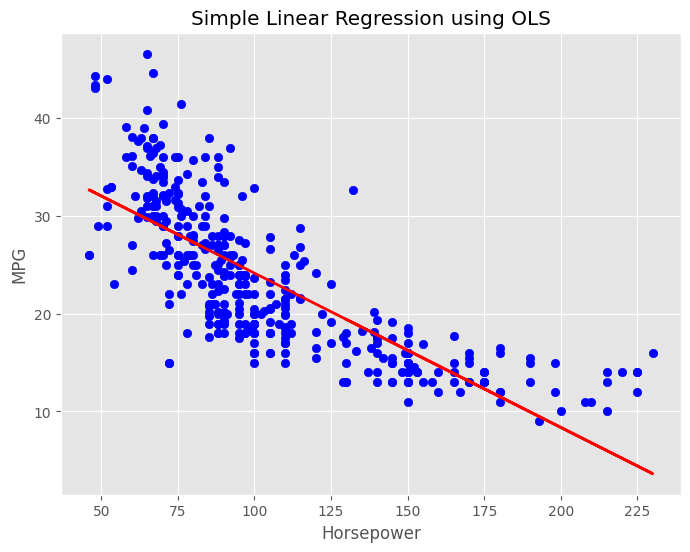

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X,y,color='blue')

plt.plot(X,y_pred,color='red',linewidth=2)

plt.xlabel("Horsepower")

plt.ylabel("MPG")

plt.title("Simple Linear Regression using OLS")

plt.show()


12.Residual Plot

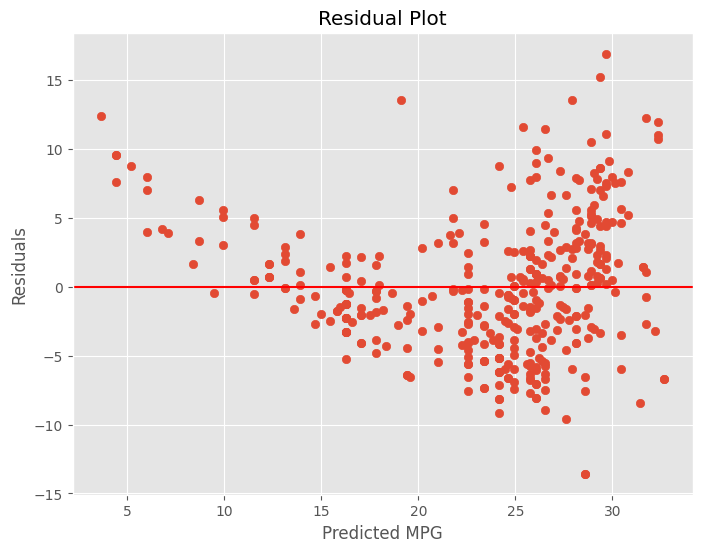

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred,residuals)

plt.axhline(0,color='red')

plt.xlabel("Predicted MPG")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()


13.Predict MPG for New Horsepower

In [ ]:
hp = 120

mpg = w[0] + w[1]*hp

print("Predicted MPG =",mpg[0])


Predicted MPG = 20.994493018732037


Conclusion:

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
